# EcoSort — AI Sub-system Prototype (Colab — auto-downloads TrashNet)
**ICT304 Assignment**
**AI&DATA LEAD: NIVETHA**
- **Technique A — SVM** on HOG + colour + GLCM features (baseline)
- **Technique B — MobileNetV2** transfer learning (primary)


In [1]:
# Imports & setup
import os, time, numpy as np, zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from collections import Counter

# huggingface_hub is pre-installed in Colab; install if missing (clean runtime)
try:
    from huggingface_hub import list_repo_files, hf_hub_download
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub"])
    from huggingface_hub import list_repo_files, hf_hub_download

os.makedirs("outputs", exist_ok=True)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style="whitegrid")

# ---- CPU-friendly settings (edit up if you have a GPU) ----
IMG = 128
CNN_EPOCHS = 8
CNN_PATIENCE = 3
FINE_TUNE = False   # set True to add a short fine-tune step

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus if gpus else "none -> running on CPU (slower, but fine)")
print("Working dir:", os.getcwd())


TensorFlow: 2.21.0
GPUs: none -> running on CPU (slower, but fine)
Working dir: /Users/nivvv/Desktop/ICT304Assignment


## Step 1 — Load TrashNet + EDA
Loads the 6-class TrashNet dataset (2,527 images) automatically from the Hugging Face Hub
(`garythung/trashnet`) — no manual upload needed, so the notebook runs on a clean Colab
runtime. If a local `dataset-resized/` folder is present it is used instead (faster for local runs).
Then plots the class distribution (note **trash** is the minority, 137) and one sample image per class.


In [2]:
# Load TrashNet — local folder first, else auto-download from the Hugging Face Hub
DATA_DIR = "dataset-resized"   # used if present (local runs); otherwise we download

# Cell-local imports so this data cell is fully self-sufficient:
import os, zipfile
import numpy as np
from PIL import Image
from collections import Counter



def find_data_dir(root):
    """Find the folder holding the 6 class subfolders (skips macOS __MACOSX junk)."""
    need = {"glass", "paper", "cardboard", "plastic", "metal", "trash"}
    for dirpath, dirnames, _ in os.walk(root):
        if "__MACOSX" in dirpath.split(os.sep):
            continue
        real = {d.lower() for d in dirnames if not d.startswith("._")}
        if need <= real:
            return dirpath
    raise FileNotFoundError("Could not find the 6 class folders in the extracted zip.")


# Self-sufficient: huggingface_hub import lives here too (not just in cell 1),
# so this cell works even if run standalone or after a kernel restart.
try:
    from huggingface_hub import list_repo_files, hf_hub_download
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub"])
    from huggingface_hub import list_repo_files, hf_hub_download

if not os.path.isdir(DATA_DIR):
    # Kaggle kernels mount attached datasets under /kaggle/input — check there first
    if os.path.isdir("/kaggle/input"):
        try:
            DATA_DIR = find_data_dir("/kaggle/input")
            print("Using Kaggle dataset mount:", DATA_DIR)
        except FileNotFoundError:
            # dataset attached as a single zip -> extract and locate the class folders
            import glob as _glob
            zips = _glob.glob("/kaggle/input/**/*.zip", recursive=True)
            if zips:
                print("Extracting attached dataset zip:", zips[0])
                with zipfile.ZipFile(zips[0]) as z:
                    z.extractall("trashnet")
                DATA_DIR = find_data_dir("trashnet")
                print("  Extracted DATA_DIR:", DATA_DIR)

if not os.path.isdir(DATA_DIR):
    print(f"No local '{DATA_DIR}' — downloading TrashNet from the Hugging Face Hub...")
    REPO = "garythung/trashnet"
    files = list_repo_files(REPO, repo_type="dataset")
    zip_name = next((f for f in files if f.lower().endswith(".zip")), None)
    if zip_name is None:
        raise FileNotFoundError(f"No .zip found in {REPO}: {files}")
    print("  Using zip:", zip_name)
    zip_path = hf_hub_download(repo_id=REPO, filename=zip_name, repo_type="dataset")
    print("  Downloaded to:", zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall("trashnet")
    DATA_DIR = find_data_dir("trashnet")
    print("  Extracted DATA_DIR:", DATA_DIR)
else:
    print(f"Using local folder: {DATA_DIR}")

class_names = sorted([d for d in os.listdir(DATA_DIR)
                      if not d.startswith("._") and os.path.isdir(os.path.join(DATA_DIR, d))])
print("Classes:", class_names)

X, y = [], []
for label, cls in enumerate(class_names):
    cls_dir = os.path.join(DATA_DIR, cls)
    for fname in sorted(os.listdir(cls_dir)):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")) and not fname.startswith("._"):
            X.append(Image.open(os.path.join(cls_dir, fname)).convert("RGB"))
            y.append(label)
y = np.array(y)

counts = Counter(y.tolist())
print("Counts:", {class_names[i]: counts[i] for i in range(len(class_names))})
print("Total images:", len(X))


Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Counts: {'cardboard': 403, 'glass': 501, 'metal': 410, 'paper': 594, 'plastic': 482, 'trash': 137}
Total images: 2527


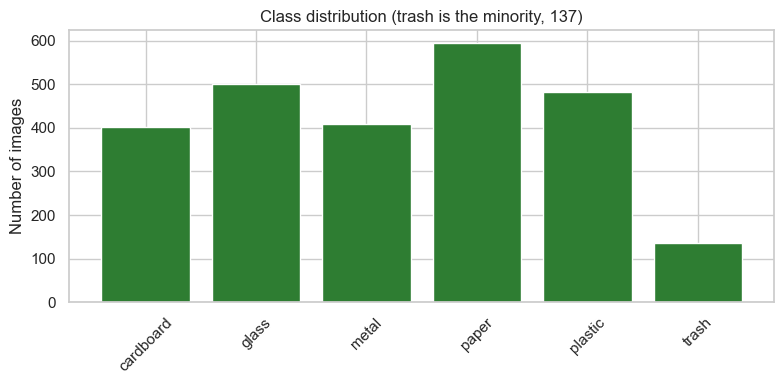

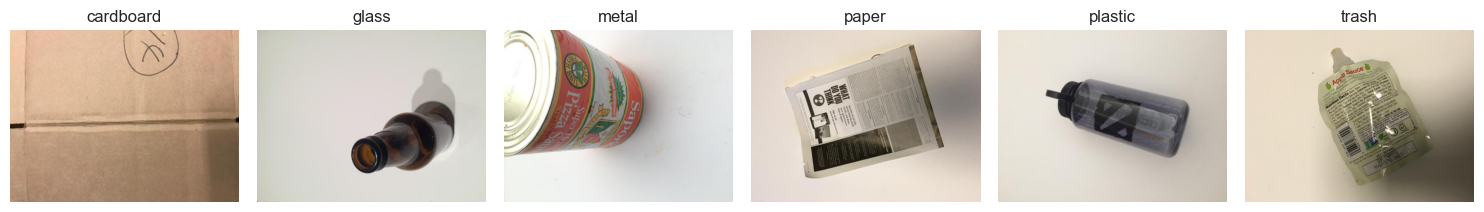

In [3]:
# EDA — class distribution + one sample image per class
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(class_names, [counts[i] for i in range(len(class_names))], color="#2E7D32")
ax.set_title("Class distribution (trash is the minority, 137)")
ax.set_ylabel("Number of images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/class_distribution.png")
plt.show()

fig, axes = plt.subplots(1, len(class_names), figsize=(15, 3))
for i, cls in enumerate(class_names):
    idx = np.where(y == i)[0][0]
    axes[i].imshow(X[idx])
    axes[i].set_title(cls)
    axes[i].axis("off")
plt.tight_layout()
plt.savefig("outputs/samples_per_class.png")
plt.show()

## Step 2 — Stratified 70 / 15 / 15 split (reproducible)
Same split for BOTH techniques so the comparison is fair. `random_state=42`.

In [4]:
# Stratified 70/15/15 split
from sklearn.model_selection import train_test_split

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)

print(f"Train: {len(X_train)}   Val: {len(X_val)}   Test: {len(X_test)}")

def ratio(labels):
    c = Counter(labels.tolist())
    return [round(c[i] / len(labels), 3) for i in range(len(class_names))]

print("Train ratios:", dict(zip(class_names, ratio(y_train))))
print("Val   ratios:", dict(zip(class_names, ratio(y_val))))
print("Test  ratios:", dict(zip(class_names, ratio(y_test))))

Train: 1768   Val: 379   Test: 380
Train ratios: {'cardboard': 0.16, 'glass': 0.198, 'metal': 0.162, 'paper': 0.235, 'plastic': 0.191, 'trash': 0.054}
Val   ratios: {'cardboard': 0.161, 'glass': 0.198, 'metal': 0.161, 'paper': 0.235, 'plastic': 0.19, 'trash': 0.055}
Test  ratios: {'cardboard': 0.158, 'glass': 0.2, 'metal': 0.163, 'paper': 0.234, 'plastic': 0.192, 'trash': 0.053}


## Step 3 — Technique A: SVM on hand-crafted features
HOG (shape) + colour histogram + GLCM (texture) → RBF SVM inside a `Pipeline`
(`StandardScaler` fits on train only — prevents leakage). `probability=True` gives the
**confidence** the routing needs.

In [5]:
# Feature extractor (HOG + colour histogram + GLCM texture)
from skimage.feature import hog, graycomatrix, graycoprops
from skimage.color import rgb2gray

def extract_features(img, size=(128, 128)):
    img = img.convert("RGB").resize(size)
    a = np.array(img)
    gray = (rgb2gray(a) * 63).astype(np.uint8)   # quantise to 64 levels -> fast GLCM
    hog_f = hog(gray, pixels_per_cell=(16, 16), cells_per_block=(2, 2), feature_vector=True)
    hist = np.concatenate([np.histogram(a[:, :, c].ravel(), bins=32, range=(0, 256))[0]
                           for c in range(3)])
    hist = hist / (hist.sum() + 1e-6)
    g = graycomatrix(gray, distances=[1, 2], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                     levels=64, symmetric=True, normed=True)
    glcm = np.concatenate([graycoprops(g, p).ravel() for p in
                           ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]])
    return np.concatenate([hog_f, hist, glcm])

print("Building SVM features (takes a few minutes)...")
t0 = time.time()
F_train = np.array([extract_features(im) for im in X_train])
F_val   = np.array([extract_features(im) for im in X_val])
F_test  = np.array([extract_features(im) for im in X_test])
print(f"Feature matrix — train: {F_train.shape}, done in {time.time() - t0:.1f}s")

Building SVM features (takes a few minutes)...
Feature matrix — train: (1768, 1900), done in 13.1s


In [6]:
# Train SVM (Pipeline + grid search) and predict with confidence
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([("scaler", StandardScaler()),
                 ("svc", SVC(kernel="rbf", probability=True))])
# Small grid for CPU speed; expand to [1,10,100] x ['scale',0.01,0.001] if you have time/GPU.
grid = GridSearchCV(pipe, {"svc__C": [1, 10], "svc__gamma": ["scale", 0.01]},
                    cv=5, scoring="f1_macro", n_jobs=-1, verbose=1)
print("Training SVM (grid search)...")
t0 = time.time()
grid.fit(F_train, y_train)
svm = grid.best_estimator_
print(f"Best params: {grid.best_params_}  (in {time.time() - t0:.1f}s)")

svm_pred = svm.predict(F_test)
svm_conf = svm.predict_proba(F_test).max(axis=1)
print("SVM ready. Example (class, confidence):",
      (class_names[svm_pred[0]], round(float(svm_conf[0]), 3)))

Training SVM (grid search)...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'svc__C': 10, 'svc__gamma': 'scale'}  (in 89.5s)
SVM ready. Example (class, confidence): ('metal', 0.62)


## Step 4 — Technique B: MobileNetV2 transfer learning
Pretrained ImageNet backbone + fresh 6-class head, fine-tuned on TrashNet. Augmentation +
class weights fight over-fitting and the "trash" minority.

In [7]:
# Build the model (freeze backbone, add augmentation, new 6-class head)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight

# Use bundled weights if present (offline Kaggle kernels); else download ImageNet weights
_local_w = "imagenet"
if os.path.isdir("/kaggle/input"):
    import glob as _g
    _hits = sorted(_g.glob("/kaggle/input/**/mobilenet_v2*_no_top.h5", recursive=True))
    if _hits:
        _local_w = _hits[0]
print("MobileNetV2 weights source:", _local_w)
base = MobileNetV2(input_shape=(IMG, IMG, 3), include_top=False, weights=_local_w)
base.trainable = False

aug = tf.keras.Sequential([layers.RandomFlip("horizontal"),
                           layers.RandomRotation(0.1),
                           layers.RandomBrightness(0.1),
                           layers.RandomZoom(0.1)])

inp = layers.Input((IMG, IMG, 3))
x = aug(inp)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(len(class_names), activation="softmax")(x)
model = models.Model(inp, out)

cw = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight = dict(zip(np.unique(y_train), cw))
print("Class weights:", {class_names[k]: round(float(v), 3) for k, v in class_weight.items()})

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
es = tf.keras.callbacks.EarlyStopping(patience=CNN_PATIENCE, restore_best_weights=True)
model.summary()

Class weights: {'cardboard': 1.045, 'glass': 0.842, 'metal': 1.027, 'paper': 0.708, 'plastic': 0.874, 'trash': 3.069}


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# tf.data pipelines and train
def make_ds(images, labels, shuffle=False):
    def gen():
        for im, lab in zip(images, labels):
            im = im.convert("RGB").resize((IMG, IMG))
            yield np.array(im, dtype="float32"), int(lab)
    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(tf.TensorSpec((IMG, IMG, 3), tf.float32),
                          tf.TensorSpec((), tf.int32)))
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.batch(32).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(X_train, y_train, shuffle=True)
val_ds   = make_ds(X_val, y_val)
test_ds  = make_ds(X_test, y_test)

print(f"Training head for up to {CNN_EPOCHS} epochs (patience={CNN_PATIENCE})...")
t0 = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=CNN_EPOCHS,
                    class_weight=class_weight, callbacks=[es])
print(f"Training done in {time.time() - t0:.1f}s")

Training head for up to 8 epochs (patience=3)...
Epoch 1/8
     55/Unknown 12s 102ms/step - accuracy: 0.3131 - loss: 1.8241

/opt/anaconda3/envs/ict203/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - accuracy: 0.4299 - loss: 1.5120 - val_accuracy: 0.5145 - val_loss: 1.1703
Epoch 2/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.6838 - loss: 0.8564 - val_accuracy: 0.6939 - val_loss: 0.8138
Epoch 3/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.7347 - loss: 0.7248 - val_accuracy: 0.7256 - val_loss: 0.7326
Epoch 4/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.7596 - loss: 0.6574 - val_accuracy: 0.7414 - val_loss: 0.6899
Epoch 5/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - accuracy: 0.7890 - loss: 0.5997 - val_accuracy: 0.7414 - val_loss: 0.7348
Epoch 6/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.7958 - loss: 0.5469 - val_accuracy: 0.7678 - val_loss: 0.6212
Epoch 7/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.8083 - loss: 0.5240 - val_accuracy: 0.7599 - val_loss: 0.6652
Epoch 8/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - accuracy: 0.8281 - loss: 0.4748 - val_accuracy: 0.7731 - val_loss: 

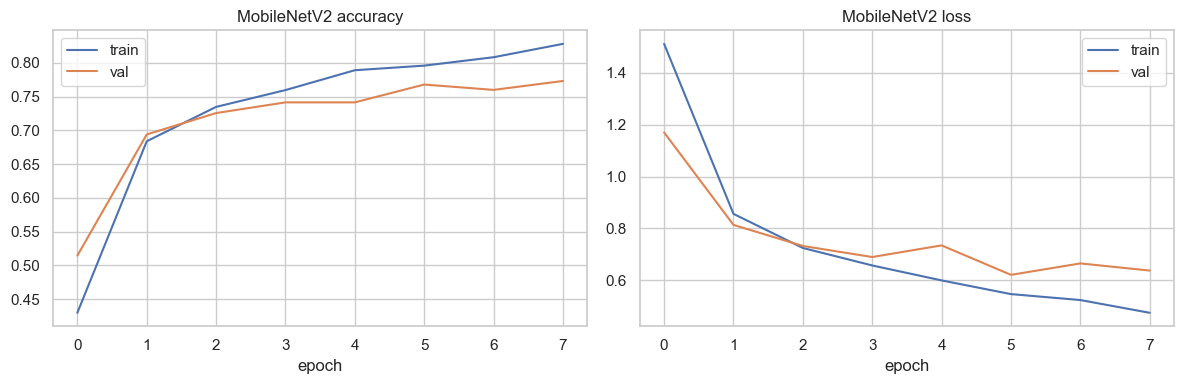

In [9]:
# Training curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history["accuracy"], label="train")
ax[0].plot(history.history["val_accuracy"], label="val")
ax[0].set_title("MobileNetV2 accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history.history["loss"], label="train")
ax[1].plot(history.history["val_loss"], label="val")
ax[1].set_title("MobileNetV2 loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout()
plt.savefig("outputs/mobilenetv2_training.png")
plt.show()

In [10]:
# Optional fine-tune, then predict with confidence
if FINE_TUNE:
    print("Fine-tuning (unfreeze top ~20 layers, low LR)...")
    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.fit(train_ds, validation_data=val_ds, epochs=3,
              class_weight=class_weight, callbacks=[es])

cnn_prob = model.predict(test_ds, verbose=0)
cnn_pred = cnn_prob.argmax(1)
cnn_conf = cnn_prob.max(1)
print("MobileNetV2 ready. Example (class, confidence):",
      (class_names[cnn_pred[0]], round(float(cnn_conf[0]), 3)))

MobileNetV2 ready. Example (class, confidence): ('metal', 0.724)


## Step 5 — Comparison + justification (the 20% criterion)
Same test set, same metrics: accuracy, macro-F1, per-class report, confusion matrix, latency.


SVM — accuracy: 0.711   macro-F1: 0.703
              precision    recall  f1-score   support

   cardboard       0.81      0.72      0.76        60
       glass       0.63      0.75      0.69        76
       metal       0.64      0.71      0.67        62
       paper       0.80      0.79      0.80        89
     plastic       0.65      0.63      0.64        73
       trash       1.00      0.50      0.67        20

    accuracy                           0.71       380
   macro avg       0.76      0.68      0.70       380
weighted avg       0.72      0.71      0.71       380



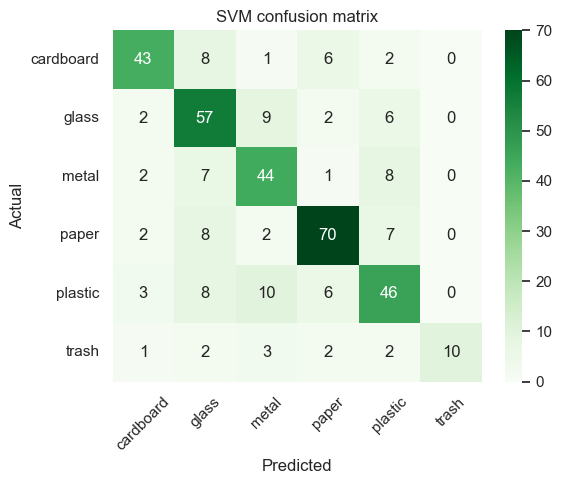


MobileNetV2 — accuracy: 0.755   macro-F1: 0.726
              precision    recall  f1-score   support

   cardboard       0.82      0.88      0.85        60
       glass       0.80      0.64      0.72        76
       metal       0.69      0.79      0.74        62
       paper       0.79      0.81      0.80        89
     plastic       0.71      0.75      0.73        73
       trash       0.64      0.45      0.53        20

    accuracy                           0.76       380
   macro avg       0.74      0.72      0.73       380
weighted avg       0.76      0.76      0.75       380



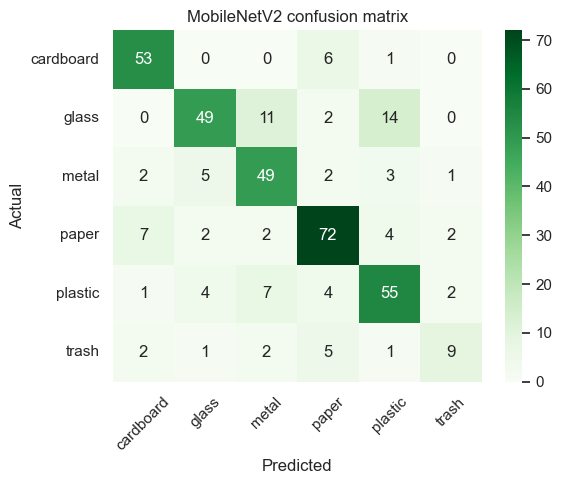

In [11]:
# Evaluate both models + confusion matrices
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

def evaluate(name, y_true, y_pred):
    acc = float(accuracy_score(y_true, y_pred))
    f1m = float(f1_score(y_true, y_pred, average="macro"))
    print(f"\n{name} — accuracy: {acc:.3f}   macro-F1: {f1m:.3f}")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f"{name} confusion matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.xticks(rotation=45); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"outputs/cm_{name}.png")
    plt.show()
    return acc, f1m

acc_svm, f1_svm = evaluate("SVM", y_test, svm_pred)
acc_cnn, f1_cnn = evaluate("MobileNetV2", y_test, cnn_pred)

In [12]:
# Inference latency (seconds per image, averaged over the test set)
t0 = time.time(); _ = svm.predict_proba(F_test)
svm_sec = (time.time() - t0) / len(F_test)

t0 = time.time(); _ = model.predict(test_ds, verbose=0)
cnn_sec = (time.time() - t0) / len(X_test)

print(f"SVM latency:         {svm_sec * 1000:.1f} ms/image")
print(f"MobileNetV2 latency: {cnn_sec * 1000:.1f} ms/image")

SVM latency:         2.3 ms/image
MobileNetV2 latency: 2.9 ms/image


/opt/anaconda3/envs/ict203/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [13]:
# Comparison table
import pandas as pd

comparison = pd.DataFrame({
    "Technique": ["SVM (HOG+colour+GLCM)", "MobileNetV2 (transfer learning)"],
    "Accuracy": [round(acc_svm, 3), round(acc_cnn, 3)],
    "Macro-F1": [round(f1_svm, 3), round(f1_cnn, 3)],
    "Latency (ms/img)": [round(svm_sec * 1000, 1), round(cnn_sec * 1000, 1)],
})
comparison

,Technique,Accuracy,Macro-F1,Latency (ms/img)
0,SVM (HOG+colour+GLCM),0.711,0.703,2.3
1,MobileNetV2 (transfer learning),0.755,0.726,2.9


## Step 6 — One-image inference demo
Feed one image → print `(class, confidence)` for both models 

True label: metal

SVM          -> class: metal      confidence: 0.620
MobileNetV2  -> class: metal      confidence: 0.724


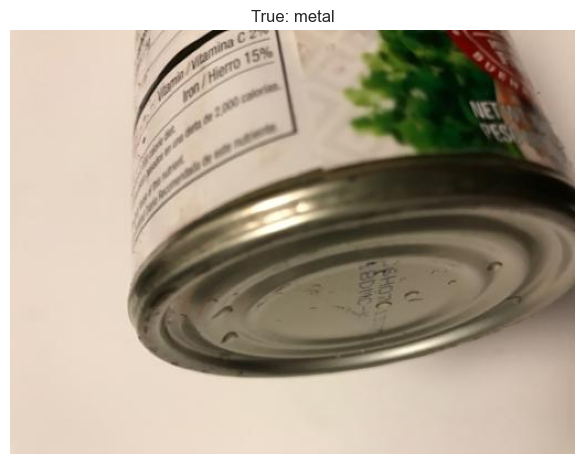

In [14]:
# One-image inference demo
i = 0  # first test image (change the index to try others)
true_label = class_names[y_test[i]]
print(f"True label: {true_label}\n")

# SVM
feat = extract_features(X_test[i]).reshape(1, -1)
proba_s = svm.predict_proba(feat)[0]
print(f"SVM          -> class: {class_names[proba_s.argmax()]:<10} confidence: {proba_s.max():.3f}")

# MobileNetV2 (model applies preprocess_input internally)
img_arr = np.array(X_test[i].convert("RGB").resize((IMG, IMG)), dtype="float32")[None, ...]
proba_c = model.predict(img_arr, verbose=0)[0]
print(f"MobileNetV2  -> class: {class_names[proba_c.argmax()]:<10} confidence: {proba_c.max():.3f}")

plt.imshow(X_test[i])
plt.title(f"True: {true_label}")
plt.axis("off")
plt.tight_layout()
plt.savefig("outputs/demo_prediction.png")
plt.show()